In [8]:
import pandas as pd
import numpy as np
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#create messy raw data
data = { "EmpId": [101, 102, "103", 104, 105, 106, 107, 108, 109, 110],
         "fullName": [
             " Alice Johnson ", "MICHEAL smith", "sarah lee", "David-Kim", None, "john brown", "Emma Wilson", "TOM davis", "Jane Miller", "Chris taylor"
         ], "Dept": ["IT", "hr", "Mktng", "IT", "Customer Care", "marketing", "Finance", None, "HR", "marketing"],
         "Age": [29, "thirty-five", 26, 31, 42, 27, 33, 30, None, 28],
         "Salary($)": ["$5500.50", "4800", "4200.75", "NaN", "6100", "4,300", "5800", "5000", "4700.0", "4400"], "JoinDate" : [ 
             "12-04-2021" , "2020.11.01" , "Jan 18, 2022" , "2019/9/25" , "07/05/18" , "2021-10-14" ,
             "2019/12/01" , "2020-03-22" , "May 10th, 2021" , "2022-02-05" ],
         "Performance": [87, "73", 90, 65, 82, 75, 88, None, "79%", "91"],
         "Remote?": ["Yes", "No", "Y", "N", "yes", "no", "Y", "Yes", None, "True"]
       }


In [10]:
#create a dataframe 
data_frame = pd.DataFrame(data)

#convert dataframe into csv file
data_frame.to_csv("data/employee_dataset.csv", index=False)

#load dataset
df = pd.read_csv("data/employee_dataset.csv")


df

,EmpId,fullName,Dept,Age,Salary($),JoinDate,Performance,Remote?
0,101,Alice Johnson,IT,29,$5500.50,12-04-2021,87,Yes
1,102,MICHEAL smith,hr,thirty-five,4800,2020.11.01,73,No
2,103,sarah lee,Mktng,26,4200.75,"Jan 18, 2022",90,Y
3,104,David-Kim,IT,31,NaN,2019/9/25,65,N
4,105,NaN,Customer Care,42,6100,07/05/18,82,yes
5,106,john brown,marketing,27,"4,300",2021-10-14,75,no
6,107,Emma Wilson,Finance,33,5800,2019/12/01,88,Y
7,108,TOM davis,NaN,30,5000,2020-03-22,NaN,Yes
8,109,Jane Miller,HR,NaN,4700.0,"May 10th, 2021",79%,NaN
9,110,Chris taylor,marketing,28,4400,2022-02-05,91,True


In [11]:
#check the info of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   EmpId        10 non-null     int64
 1   fullName     9 non-null      str  
 2   Dept         9 non-null      str  
 3   Age          9 non-null      str  
 4   Salary($)    9 non-null      str  
 5   JoinDate     10 non-null     str  
 6   Performance  9 non-null      str  
 7   Remote?      9 non-null      str  
dtypes: int64(1), str(7)
memory usage: 772.0 bytes


In [12]:
#get the dataset shape
df.shape

(10, 8)

In [13]:
#get the first five rows
df.head()

,EmpId,fullName,Dept,Age,Salary($),JoinDate,Performance,Remote?
0,101,Alice Johnson,IT,29,$5500.50,12-04-2021,87,Yes
1,102,MICHEAL smith,hr,thirty-five,4800,2020.11.01,73,No
2,103,sarah lee,Mktng,26,4200.75,"Jan 18, 2022",90,Y
3,104,David-Kim,IT,31,NaN,2019/9/25,65,N
4,105,NaN,Customer Care,42,6100,07/05/18,82,yes


In [14]:
#get the dataset colunms
df.columns

Index(['EmpId', 'fullName', 'Dept', 'Age', 'Salary($)', 'JoinDate',
       'Performance', 'Remote?'],
      dtype='str')

In [15]:
#check missing value
df.isnull().sum()

EmpId          0
fullName       1
Dept           1
Age            1
Salary($)      1
JoinDate       0
Performance    1
Remote?        1
dtype: int64

In [16]:
#inspect unique values in columns
print(df['Dept'].unique())
print(df['Age'].unique())
print(df['Remote?'].unique())

<StringArray>
['IT', 'hr', 'Mktng', 'Customer Care', 'marketing', 'Finance', nan, 'HR']
Length: 8, dtype: str
<StringArray>
['29', 'thirty-five', '26', '31', '42', '27', '33', '30', nan, '28']
Length: 10, dtype: str
<StringArray>
['Yes', 'No', 'Y', 'N', 'yes', 'no', nan, 'True']
Length: 8, dtype: str


In [17]:
#access salary value
df['Salary($)'].to_list()

['$5500.50',
 '4800',
 '4200.75',
 nan,
 '6100',
 '4,300',
 '5800',
 '5000',
 '4700.0',
 '4400']

In [18]:
df['fullName'].to_list()

[' Alice Johnson ',
 'MICHEAL smith',
 'sarah lee',
 'David-Kim',
 nan,
 'john brown',
 'Emma Wilson',
 'TOM davis',
 'Jane Miller',
 'Chris taylor']

In [19]:
df['Salary($)'].head()

0    $5500.50
1        4800
2     4200.75
3         NaN
4        6100
Name: Salary($), dtype: str

In [20]:
#start cleaning inconsistent values
#clean columns name
df.rename(columns={
    "Empid": "emp_id",
    "fullName": "full_name",
    "Dept": "department",
    "Age": "age",
    "Salary($)": "salary",
    "JoinDate": "join_date",
    "Performance": "performance",
    "Remote?": "remote"
}, inplace=True)
df

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29,$5500.50,12-04-2021,87,Yes
1,102,MICHEAL smith,hr,thirty-five,4800,2020.11.01,73,No
2,103,sarah lee,Mktng,26,4200.75,"Jan 18, 2022",90,Y
3,104,David-Kim,IT,31,NaN,2019/9/25,65,N
4,105,NaN,Customer Care,42,6100,07/05/18,82,yes
5,106,john brown,marketing,27,"4,300",2021-10-14,75,no
6,107,Emma Wilson,Finance,33,5800,2019/12/01,88,Y
7,108,TOM davis,NaN,30,5000,2020-03-22,NaN,Yes
8,109,Jane Miller,HR,NaN,4700.0,"May 10th, 2021",79%,NaN
9,110,Chris taylor,marketing,28,4400,2022-02-05,91,True


In [21]:
#clean incosistence values on full_name
df['full_name'] = (
    df['full_name']
    .str.strip()
    .str.title()
    .str.replace(r"[\s-]+", " ", regex=True)
)
df['full_name'].to_list()

['Alice Johnson',
 'Micheal Smith',
 'Sarah Lee',
 'David Kim',
 nan,
 'John Brown',
 'Emma Wilson',
 'Tom Davis',
 'Jane Miller',
 'Chris Taylor']

In [22]:
#clean incosistence values as department
df.replace({
    "hr": "HR",
    "Mktng": "Marketing",
    "marketing": "Marketing",
    None : np.nan
}, inplace=True)
df['department'].to_list()

['IT',
 'HR',
 'Marketing',
 'IT',
 'Customer Care',
 'Marketing',
 'Finance',
 nan,
 'HR',
 'Marketing']

In [102]:
#clean incosistency values in age
def clean_age(value):
    if value =="thirty-five":
        return 35
    elif isinstance(value, (int, float)):
        return value
    elif isinstance(value, str) and value.isdigit():
        return int(value)
    else:
        return np.nan
df['age'] = df['age'].apply(clean_age)

df['age']
        

0    29.0
1    35.0
2    26.0
3    31.0
4    42.0
5    27.0
6    33.0
7    30.0
8    30.0
9    28.0
Name: age, dtype: float64

In [103]:
# clean incosistency values on Salary
df['salary'] = (
    df['salary']
    .astype(str)
    .replace(r"[$,]", "", regex=True)
    .replace("NaN", np.nan)
    .astype(float)
    
)
df['salary']


0    5500.50
1    4800.00
2    4200.75
3    4800.00
4    6100.00
5    4300.00
6    5800.00
7    5000.00
8    4700.00
9    4400.00
Name: salary, dtype: float64

In [104]:
#clean incosistency values on performance
df['performance'] = (
    df['performance']
    .astype(str)
    .str.replace(r"[%]", "", regex=True)
    .replace("None", np.nan)
    .astype(float)
    
)
df['performance']


0    87.0
1    73.0
2    90.0
3    65.0
4    82.0
5    75.0
6    88.0
7    82.0
8    79.0
9    91.0
Name: performance, dtype: float64

In [105]:
#clean incosistency values on remote
df.replace({
    "Y": "Yes",
    "N": "No",
    "yes": "Yes",
    "no": "No",
    "True": "Yes",
    None : np.nan
}, inplace=True)

df['remote']


0    Yes
1     No
2    Yes
3     No
4    Yes
5     No
6    Yes
7    Yes
8    Yes
9    Yes
Name: remote, dtype: str

In [181]:
#clean incosistency value in join_date column
#df['join_date'] = pd.to_datetime(df['join_date'],errors="coerce")
#df['join_date']

def date_parser(date_str):
    try:
        return parser.parse(date_str, dayfirst=True)
    except Exception:
        return pd.NaT
df['join_date'] = df['join_date'].apply(date_parser)  
df['join_date']

0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
5   NaT
6   NaT
7   NaT
8   NaT
9   NaT
Name: join_date, dtype: datetime64[s]

In [107]:
# clean incosistence values in employee ID
df['EmpId'] = pd.to_numeric(df['EmpId'], errors='coerce')
df['EmpId']


0    101
1    102
2    103
3    104
4    105
5    106
6    107
7    108
8    109
9    110
Name: EmpId, dtype: int64

In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype        
---  ------       --------------  -----        
 0   EmpId        10 non-null     int64        
 1   full_name    10 non-null     str          
 2   department   10 non-null     str          
 3   age          10 non-null     float64      
 4   salary       10 non-null     float64      
 5   join_date    0 non-null      datetime64[s]
 6   performance  10 non-null     float64      
 7   remote       10 non-null     str          
dtypes: datetime64[s](1), float64(3), int64(1), str(3)
memory usage: 772.0 bytes


In [109]:
#handling missing values
df['full_name'] = df['full_name'].fillna('Unknown')
df['full_name']

0    Alice Johnson
1    Micheal Smith
2        Sarah Lee
3        David Kim
4          Unknown
5       John Brown
6      Emma Wilson
7        Tom Davis
8      Jane Miller
9     Chris Taylor
Name: full_name, dtype: str

In [110]:
# most occurrence value
df['department'] = df['department'].fillna(df['department'].mode()[0])
df['department']

0               IT
1               HR
2        Marketing
3               IT
4    Customer Care
5        Marketing
6          Finance
7        Marketing
8               HR
9        Marketing
Name: department, dtype: str

In [111]:
#handling missing values
df['age'] = df['age'].fillna(df['age'].median())
df['age']

0    29.0
1    35.0
2    26.0
3    31.0
4    42.0
5    27.0
6    33.0
7    30.0
8    30.0
9    28.0
Name: age, dtype: float64

In [112]:
df['salary'] = df['salary'].fillna(df['salary'].median())
df['salary']

0    5500.50
1    4800.00
2    4200.75
3    4800.00
4    6100.00
5    4300.00
6    5800.00
7    5000.00
8    4700.00
9    4400.00
Name: salary, dtype: float64

In [113]:
df

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [114]:
df['performance'] = df['performance'].fillna(df['performance'].median())
df['performance']

0    87.0
1    73.0
2    90.0
3    65.0
4    82.0
5    75.0
6    88.0
7    82.0
8    79.0
9    91.0
Name: performance, dtype: float64

In [115]:
df['remote'] = df['remote'].fillna(df['remote'].mode()[0])
df['remote']

0    Yes
1     No
2    Yes
3     No
4    Yes
5     No
6    Yes
7    Yes
8    Yes
9    Yes
Name: remote, dtype: str

In [116]:
df

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [117]:
#working with filtering
df['full_name']

0    Alice Johnson
1    Micheal Smith
2        Sarah Lee
3        David Kim
4          Unknown
5       John Brown
6      Emma Wilson
7        Tom Davis
8      Jane Miller
9     Chris Taylor
Name: full_name, dtype: str

In [118]:
df.head()

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes


In [119]:
df[['full_name', 'salary', 'performance']]

,full_name,salary,performance
0,Alice Johnson,5500.50,87.0
1,Micheal Smith,4800.00,73.0
2,Sarah Lee,4200.75,90.0
3,David Kim,4800.00,65.0
4,Unknown,6100.00,82.0
5,John Brown,4300.00,75.0
6,Emma Wilson,5800.00,88.0
7,Tom Davis,5000.00,82.0
8,Jane Miller,4700.00,79.0
9,Chris Taylor,4400.00,91.0


In [120]:
df.iloc[0:3, 0:3]

,EmpId,full_name,department
0,101,Alice Johnson,IT
1,102,Micheal Smith,HR
2,103,Sarah Lee,Marketing


In [121]:
df.loc[df['salary'] >= 5000]

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.5,NaT,87.0,Yes
4,105,Unknown,Customer Care,42.0,6100.0,NaT,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.0,NaT,88.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.0,NaT,82.0,Yes


In [122]:
df.loc[df['salary'] <= 5000]

,EmpId,full_name,department,age,salary,join_date,performance,remote
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [123]:
df.loc[df['salary'] >= 5000, ['full_name', 'department', 'salary']]

,full_name,department,salary
0,Alice Johnson,IT,5500.5
4,Unknown,Customer Care,6100.0
6,Emma Wilson,Finance,5800.0
7,Tom Davis,Marketing,5000.0


In [124]:
df.loc[df['department'] == 'IT']

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.5,NaT,87.0,Yes
3,104,David Kim,IT,31.0,4800.0,NaT,65.0,No


In [125]:
df[df['department'] == 'IT']

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.5,NaT,87.0,Yes
3,104,David Kim,IT,31.0,4800.0,NaT,65.0,No


In [126]:
df.loc[df['department'] != 'HR']

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [127]:
df.loc[df['age'] > 30]

,EmpId,full_name,department,age,salary,join_date,performance,remote
1,102,Micheal Smith,HR,35.0,4800.0,NaT,73.0,No
3,104,David Kim,IT,31.0,4800.0,NaT,65.0,No
4,105,Unknown,Customer Care,42.0,6100.0,NaT,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.0,NaT,88.0,Yes


In [128]:
df[
    (df['salary'] > 50000) & (df['remote'] == 'Yes')
]

,EmpId,full_name,department,age,salary,join_date,performance,remote


In [129]:
df[
    (df['salary'] > 50000) | (df['remote'] == 'Yes')
]

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [130]:
df[
    (df['salary'] > 5000) & (df['remote'] == 'Yes')
]

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.5,NaT,87.0,Yes
4,105,Unknown,Customer Care,42.0,6100.0,NaT,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.0,NaT,88.0,Yes


In [131]:
df[
    (df['salary'] > 5000) & (df['remote'] == 'No')
]

,EmpId,full_name,department,age,salary,join_date,performance,remote


In [132]:
df[
    (df['salary'] < 5000) & (df['remote'] == 'Yes')
]

,EmpId,full_name,department,age,salary,join_date,performance,remote
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [133]:
df[
    (df['performance'] < 50) | (df['remote'] == 'Yes')
]

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [134]:
df[
    (df['performance'] < 50) | (df['remote'] == 'True')
]

,EmpId,full_name,department,age,salary,join_date,performance,remote


In [135]:
df[df['department'].isin(['IT', 'Finance'])]

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.5,NaT,87.0,Yes
3,104,David Kim,IT,31.0,4800.0,NaT,65.0,No
6,107,Emma Wilson,Finance,33.0,5800.0,NaT,88.0,Yes


In [136]:
df[df['department'].isin(['IT', 'Accounting'])]

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.5,NaT,87.0,Yes
3,104,David Kim,IT,31.0,4800.0,NaT,65.0,No


In [137]:
df[df['department'].str.startswith("M")]

,EmpId,full_name,department,age,salary,join_date,performance,remote
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [138]:
df[df['full_name'].str.contains('John')]

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.5,NaT,87.0,Yes
5,106,John Brown,Marketing,27.0,4300.0,NaT,75.0,No


In [139]:
df[df['full_name'].str.contains('john', case=False)]

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.5,NaT,87.0,Yes
5,106,John Brown,Marketing,27.0,4300.0,NaT,75.0,No


In [140]:
#working with values
df.sort_values('salary')


,EmpId,full_name,department,age,salary,join_date,performance,remote
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes


In [141]:
df.sort_values('salary', ascending=False)

,EmpId,full_name,department,age,salary,join_date,performance,remote
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes


In [142]:
df.sort_values('performance', ascending=False)

,EmpId,full_name,department,age,salary,join_date,performance,remote
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No


In [143]:
df.sort_values('performance', ascending=False).head()

,EmpId,full_name,department,age,salary,join_date,performance,remote
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes


In [144]:
df.sort_values('department')

,EmpId,full_name,department,age,salary,join_date,performance,remote
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [145]:
df.sort_values(['department','performance'], ascending=[True, False])

,EmpId,full_name,department,age,salary,join_date,performance,remote
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No


In [146]:
df.sort_values(['department','performance'], ascending=[False, True])

,EmpId,full_name,department,age,salary,join_date,performance,remote
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes


In [147]:
df.sort_values(['performance', 'department'], ascending=[False, True])

,EmpId,full_name,department,age,salary,join_date,performance,remote
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No


In [148]:
#working with value counting
df['department'].value_counts()

department
Marketing        4
IT               2
HR               2
Customer Care    1
Finance          1
Name: count, dtype: int64

In [149]:
df['remote'].value_counts()

remote
Yes    7
No     3
Name: count, dtype: int64

In [150]:
df['remote'].value_counts(normalize=True)

remote
Yes    0.7
No     0.3
Name: proportion, dtype: float64

In [151]:
df['department'].value_counts(normalize=True)

department
Marketing        0.4
IT               0.2
HR               0.2
Customer Care    0.1
Finance          0.1
Name: proportion, dtype: float64

In [152]:
data1 = {
    "department": ["IT", "HR", "Finance", "Marketing", "R&D", "Operations", "Sales", "Logistics", "Procurement", "Customer Service"],
    "manager": [
        "Tom Hanks", "Susan Lee", "Robert Miles", 
        "Mark Chan", "Sarah Connor", "James Nwosu", "Adaeze Obi", 
        "Daniel Smith", "Amina Yusuf", "Grace Ojo"
    ],
    "department_budget": [200000, 150000, 250000, 180000, 300000, 220000, 210000, 195000, 230000, 170000],
    "office_location": [
        "Lagos", "Abuja", "Port Harcourt", "Ibadan", "Enugu", "Kano",
        "Lagos", "Calabar", "Abuja", "Kano"
    ]
}

df1 = pd.DataFrame(data1)

#convert into csv file
df1.to_csv("data/department_data.csv", index=False)

df1 = pd.read_csv("data/department_data.csv")

df1.head()

,department,manager,department_budget,office_location
0,IT,Tom Hanks,200000,Lagos
1,HR,Susan Lee,150000,Abuja
2,Finance,Robert Miles,250000,Port Harcourt
3,Marketing,Mark Chan,180000,Ibadan
4,R&D,Sarah Connor,300000,Enugu


In [153]:
df1

,department,manager,department_budget,office_location
0,IT,Tom Hanks,200000,Lagos
1,HR,Susan Lee,150000,Abuja
2,Finance,Robert Miles,250000,Port Harcourt
3,Marketing,Mark Chan,180000,Ibadan
4,R&D,Sarah Connor,300000,Enugu
5,Operations,James Nwosu,220000,Kano
6,Sales,Adaeze Obi,210000,Lagos
7,Logistics,Daniel Smith,195000,Calabar
8,Procurement,Amina Yusuf,230000,Abuja
9,Customer Service,Grace Ojo,170000,Kano


In [154]:

#combine employee data and the department data together
merge_df = pd.merge(df, df1, how='inner')
merge_df

,EmpId,full_name,department,age,salary,join_date,performance,remote,manager,department_budget,office_location
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes,Tom Hanks,200000,Lagos
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No,Susan Lee,150000,Abuja
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes,Mark Chan,180000,Ibadan
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No,Tom Hanks,200000,Lagos
4,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No,Mark Chan,180000,Ibadan
5,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes,Robert Miles,250000,Port Harcourt
6,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes,Mark Chan,180000,Ibadan
7,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes,Susan Lee,150000,Abuja
8,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes,Mark Chan,180000,Ibadan


In [155]:
df1

,department,manager,department_budget,office_location
0,IT,Tom Hanks,200000,Lagos
1,HR,Susan Lee,150000,Abuja
2,Finance,Robert Miles,250000,Port Harcourt
3,Marketing,Mark Chan,180000,Ibadan
4,R&D,Sarah Connor,300000,Enugu
5,Operations,James Nwosu,220000,Kano
6,Sales,Adaeze Obi,210000,Lagos
7,Logistics,Daniel Smith,195000,Calabar
8,Procurement,Amina Yusuf,230000,Abuja
9,Customer Service,Grace Ojo,170000,Kano


In [156]:
df

,EmpId,full_name,department,age,salary,join_date,performance,remote
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes


In [157]:
left_df = pd.merge(df, df1, how='left')
left_df

,EmpId,full_name,department,age,salary,join_date,performance,remote,manager,department_budget,office_location
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes,Tom Hanks,200000.0,Lagos
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No,Susan Lee,150000.0,Abuja
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes,Mark Chan,180000.0,Ibadan
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No,Tom Hanks,200000.0,Lagos
4,105,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes,NaN,NaN,NaN
5,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No,Mark Chan,180000.0,Ibadan
6,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes,Robert Miles,250000.0,Port Harcourt
7,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes,Mark Chan,180000.0,Ibadan
8,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes,Susan Lee,150000.0,Abuja
9,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes,Mark Chan,180000.0,Ibadan


In [158]:
right_df = pd.merge(df, df1, how='right')
right_df

,EmpId,full_name,department,age,salary,join_date,performance,remote,manager,department_budget,office_location
0,101.0,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes,Tom Hanks,200000,Lagos
1,104.0,David Kim,IT,31.0,4800.00,NaT,65.0,No,Tom Hanks,200000,Lagos
2,102.0,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No,Susan Lee,150000,Abuja
3,109.0,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes,Susan Lee,150000,Abuja
4,107.0,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes,Robert Miles,250000,Port Harcourt
5,103.0,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes,Mark Chan,180000,Ibadan
6,106.0,John Brown,Marketing,27.0,4300.00,NaT,75.0,No,Mark Chan,180000,Ibadan
7,108.0,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes,Mark Chan,180000,Ibadan
8,110.0,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes,Mark Chan,180000,Ibadan
9,NaN,NaN,R&D,NaN,NaN,NaT,NaN,NaN,Sarah Connor,300000,Enugu


In [159]:
full_df = pd.merge(df, df1, how='outer')
full_df

,EmpId,full_name,department,age,salary,join_date,performance,remote,manager,department_budget,office_location
0,105.0,Unknown,Customer Care,42.0,6100.00,NaT,82.0,Yes,NaN,NaN,NaN
1,NaN,NaN,Customer Service,NaN,NaN,NaT,NaN,NaN,Grace Ojo,170000.0,Kano
2,107.0,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes,Robert Miles,250000.0,Port Harcourt
3,102.0,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No,Susan Lee,150000.0,Abuja
4,109.0,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes,Susan Lee,150000.0,Abuja
5,101.0,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes,Tom Hanks,200000.0,Lagos
6,104.0,David Kim,IT,31.0,4800.00,NaT,65.0,No,Tom Hanks,200000.0,Lagos
7,NaN,NaN,Logistics,NaN,NaN,NaT,NaN,NaN,Daniel Smith,195000.0,Calabar
8,103.0,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes,Mark Chan,180000.0,Ibadan
9,106.0,John Brown,Marketing,27.0,4300.00,NaT,75.0,No,Mark Chan,180000.0,Ibadan


In [160]:
#average salary by department
merge_df.groupby('department')['salary'].mean()

department
Finance      5800.0000
HR           4750.0000
IT           5150.2500
Marketing    4475.1875
Name: salary, dtype: float64

In [161]:
merge_df.groupby('department')['salary'].mean().sort_values(ascending=False)

department
Finance      5800.0000
IT           5150.2500
HR           4750.0000
Marketing    4475.1875
Name: salary, dtype: float64

In [162]:
#average salary and performance by department
merge_df.groupby('department')[['salary','performance']].mean()

,salary,performance
department,,
Finance,5800.0000,88.0
HR,4750.0000,76.0
IT,5150.2500,76.0
Marketing,4475.1875,84.5


In [163]:
merge_df.groupby('department')[['salary', 'performance']].mean().sort_values(by=['salary', 'performance'], ascending=[False, False])

,salary,performance
department,,
Finance,5800.0000,88.0
IT,5150.2500,76.0
HR,4750.0000,76.0
Marketing,4475.1875,84.5


In [164]:
merge_df

,EmpId,full_name,department,age,salary,join_date,performance,remote,manager,department_budget,office_location
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes,Tom Hanks,200000,Lagos
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No,Susan Lee,150000,Abuja
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes,Mark Chan,180000,Ibadan
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No,Tom Hanks,200000,Lagos
4,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No,Mark Chan,180000,Ibadan
5,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes,Robert Miles,250000,Port Harcourt
6,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes,Mark Chan,180000,Ibadan
7,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes,Susan Lee,150000,Abuja
8,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes,Mark Chan,180000,Ibadan


In [165]:
#write a multiple aggregation method
merge_df.groupby('department').agg(
    avg_salary=('salary', 'mean'),
    total_salary=('salary', 'sum'),
    employee_count=('salary', 'count'),
    min_salary=('salary', 'min'),
    max_salary=('salary', 'max')
)

,avg_salary,total_salary,employee_count,min_salary,max_salary
department,,,,,
Finance,5800.0000,5800.00,1,5800.00,5800.0
HR,4750.0000,9500.00,2,4700.00,4800.0
IT,5150.2500,10300.50,2,4800.00,5500.5
Marketing,4475.1875,17900.75,4,4200.75,5000.0


In [166]:
merge_df.groupby('department').agg(
    avg_salary=('salary', 'mean'),
    avg_performance=('performance', 'mean'),
    employee_count=('EmpId', 'count'),
    
)

,avg_salary,avg_performance,employee_count
department,,,
Finance,5800.0000,88.0,1
HR,4750.0000,76.0,2
IT,5150.2500,76.0,2
Marketing,4475.1875,84.5,4


In [167]:
merge_df.groupby('department')['salary'].mean().reset_index()

,department,salary
0,Finance,5800.0000
1,HR,4750.0000
2,IT,5150.2500
3,Marketing,4475.1875


In [168]:
merge_df.groupby('department').agg(
    avg_salary=('salary', 'mean'),
    avg_performance=('performance', 'mean'),
    employee_count=('EmpId', 'count'),
    
).reset_index()

,department,avg_salary,avg_performance,employee_count
0,Finance,5800.0000,88.0,1
1,HR,4750.0000,76.0,2
2,IT,5150.2500,76.0,2
3,Marketing,4475.1875,84.5,4


In [169]:
merge_df.groupby('department').agg(
    avg_salary=('salary', 'mean'),
    total_salary=('salary', 'sum'),
    employee_count=('salary', 'count'),
    min_salary=('salary', 'min'),
    max_salary=('salary', 'max')
).reset_index()

,department,avg_salary,total_salary,employee_count,min_salary,max_salary
0,Finance,5800.0000,5800.00,1,5800.00,5800.0
1,HR,4750.0000,9500.00,2,4700.00,4800.0
2,IT,5150.2500,10300.50,2,4800.00,5500.5
3,Marketing,4475.1875,17900.75,4,4200.75,5000.0


In [170]:
merge_df.groupby('department')['salary'].apply(lambda x: x.std())

department
Finance             NaN
HR            70.710678
IT           495.328300
Marketing    359.206497
Name: salary, dtype: float64

In [171]:
merge_df.groupby('department').apply(lambda x: x['salary'].mean() >= 5000)

department
Finance       True
HR           False
IT            True
Marketing    False
dtype: bool

In [172]:
merge_df.groupby('department').filter(lambda x: x['salary'].mean() >= 5000)

,EmpId,full_name,department,age,salary,join_date,performance,remote,manager,department_budget,office_location
0,101,Alice Johnson,IT,29.0,5500.5,NaT,87.0,Yes,Tom Hanks,200000,Lagos
3,104,David Kim,IT,31.0,4800.0,NaT,65.0,No,Tom Hanks,200000,Lagos
5,107,Emma Wilson,Finance,33.0,5800.0,NaT,88.0,Yes,Robert Miles,250000,Port Harcourt


In [173]:
merge_df['department_avg_salary'] = merge_df.groupby('department')['salary'].transform('mean')
merge_df

,EmpId,full_name,department,age,salary,join_date,performance,remote,manager,department_budget,office_location,department_avg_salary
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes,Tom Hanks,200000,Lagos,5150.2500
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No,Susan Lee,150000,Abuja,4750.0000
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes,Mark Chan,180000,Ibadan,4475.1875
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No,Tom Hanks,200000,Lagos,5150.2500
4,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No,Mark Chan,180000,Ibadan,4475.1875
5,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes,Robert Miles,250000,Port Harcourt,5800.0000
6,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes,Mark Chan,180000,Ibadan,4475.1875
7,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes,Susan Lee,150000,Abuja,4750.0000
8,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes,Mark Chan,180000,Ibadan,4475.1875


In [174]:
merge_df.groupby('department')['salary'].apply(lambda x: x.max() - x.min())

department
Finance        0.00
HR           100.00
IT           700.50
Marketing    799.25
Name: salary, dtype: float64

In [175]:
#detect an outliers in salary column
Q1 = merge_df['salary'].quantile(0.25)
Q3 = merge_df['salary'].quantile(0.75)
Q1
Q3
IQR = Q3 -Q1
IQR

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ( merge_df['salary'] < lower_bound) | ( merge_df['salary'] > upper_bound)

print(outliers.sum())

0


In [176]:
lower_bound

np.float64(3500.0)

In [177]:
upper_bound

np.float64(5900.0)

In [178]:
merge_df.describe()

,EmpId,age,salary,join_date,performance,department_budget,department_avg_salary
count,9.000000,9.000000,9.000000,0,9.000000,9.000000,9.000000
mean,105.555556,29.888889,4833.472222,NaT,81.111111,185555.555556,4833.472222
min,101.000000,26.000000,4200.750000,NaT,65.000000,150000.000000,4475.187500
25%,103.000000,28.000000,4400.000000,NaT,75.000000,180000.000000,4475.187500
50%,106.000000,30.000000,4800.000000,NaT,82.000000,180000.000000,4750.000000
75%,108.000000,31.000000,5000.000000,NaT,88.000000,200000.000000,5150.250000
max,110.000000,35.000000,5800.000000,NaT,91.000000,250000.000000,5800.000000
std,3.205897,2.848001,536.157312,NaN,8.852181,30046.260629,455.834298


In [179]:
#exclude an outliers in dataframe

Q1 = merge_df['salary'].quantile(0.25)
Q3 = merge_df['salary'].quantile(0.75)
Q1
Q3
IQR = Q3 -Q1
IQR

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ( merge_df['salary'] < lower_bound) | ( merge_df['salary'] > upper_bound)

print(outliers.sum())

new_df = merge_df[
    ( merge_df['salary'] > lower_bound) & ( merge_df['salary'] < upper_bound)
] 

new_df

0


,EmpId,full_name,department,age,salary,join_date,performance,remote,manager,department_budget,office_location,department_avg_salary
0,101,Alice Johnson,IT,29.0,5500.50,NaT,87.0,Yes,Tom Hanks,200000,Lagos,5150.2500
1,102,Micheal Smith,HR,35.0,4800.00,NaT,73.0,No,Susan Lee,150000,Abuja,4750.0000
2,103,Sarah Lee,Marketing,26.0,4200.75,NaT,90.0,Yes,Mark Chan,180000,Ibadan,4475.1875
3,104,David Kim,IT,31.0,4800.00,NaT,65.0,No,Tom Hanks,200000,Lagos,5150.2500
4,106,John Brown,Marketing,27.0,4300.00,NaT,75.0,No,Mark Chan,180000,Ibadan,4475.1875
5,107,Emma Wilson,Finance,33.0,5800.00,NaT,88.0,Yes,Robert Miles,250000,Port Harcourt,5800.0000
6,108,Tom Davis,Marketing,30.0,5000.00,NaT,82.0,Yes,Mark Chan,180000,Ibadan,4475.1875
7,109,Jane Miller,HR,30.0,4700.00,NaT,79.0,Yes,Susan Lee,150000,Abuja,4750.0000
8,110,Chris Taylor,Marketing,28.0,4400.00,NaT,91.0,Yes,Mark Chan,180000,Ibadan,4475.1875


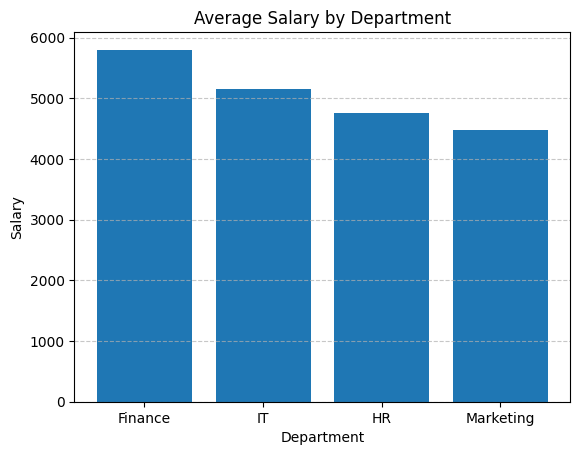

In [188]:
#average salary by department
df_sorted = merge_df.sort_values('department_avg_salary', ascending=False)
plt.bar(df_sorted['department'], df_sorted['department_avg_salary'])
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.grid(axis='y', linestyle='--', alpha=0.7,)

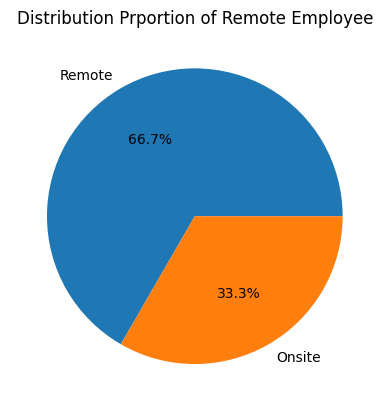

In [189]:
#Distribution proportion of remote employee
remote_status = ['Remote', 'Onsite']
plt.pie(merge_df['remote'].value_counts(), labels=remote_status, autopct="%1.1f%%")
plt.title("Distribution Prportion of Remote Employee")
plt.show()